<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/new_crystal_density_calculation_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ase

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate
import os
import pandas as pd
from skimage.feature import peak_local_max
np.random.seed(6)

In [ ]:
MATERIALS = [

    # FCC
    {'element': 'Au', 'structure': 'fcc', 'a': 4.08},
    {'element': 'Al', 'structure': 'fcc', 'a': 4.05},
    {'element': 'Cu', 'structure': 'fcc', 'a': 3.61},
    {'element': 'Ni', 'structure': 'fcc', 'a': 3.52},
    {'element': 'Ag', 'structure': 'fcc', 'a': 4.09},
    {'element': 'Pt', 'structure': 'fcc', 'a': 3.92},

    # BCC
    {'element': 'Fe', 'structure': 'bcc', 'a': 2.87},
    {'element': 'Cr', 'structure': 'bcc', 'a': 2.91},
    {'element': 'W',  'structure': 'bcc', 'a': 3.16},
    {'element': 'Mo', 'structure': 'bcc', 'a': 3.15},
    {'element': 'Nb', 'structure': 'bcc', 'a': 3.30},
    {'element': 'V',  'structure': 'bcc', 'a': 3.03},

    # HCP
    {'element': 'Ti', 'structure': 'hcp', 'a': 2.95, 'c': 4.68},
    {'element': 'Mg', 'structure': 'hcp', 'a': 3.21, 'c': 5.21},
    {'element': 'Zn', 'structure': 'hcp', 'a': 2.66, 'c': 4.95},
    {'element': 'Co', 'structure': 'hcp', 'a': 2.51, 'c': 4.07},
    {'element': 'Zr', 'structure': 'hcp', 'a': 3.23, 'c': 5.15},
    {'element': 'Be', 'structure': 'hcp', 'a': 2.29, 'c': 3.58},
]

In [ ]:
ORIENTATIONS = {

    'fcc': ['100', '110', '111'],

    'bcc': ['100', '110', '111'],

    'hcp': ['0001', '1010']

}

In [ ]:
AVOGADRO = 6.022e23

ATOMS_PER_CELL = {
    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

def compute_density(structure, mass, lattice_constant):
    n = ATOMS_PER_CELL[structure]
    a_cm = lattice_constant * 1e-8
    volume = a_cm**3
    density = (n * mass) / (AVOGADRO * volume)

    return density

In [ ]:
def generate_crystal_image(
    material,
    orientation='100',
    repetitions=(8,8,4),
    grid_size=128,
    sigma=2,
    noise_level=0.01,
    rotation_angle=0
):

    structure = material['structure']

    if structure == 'hcp':
        atoms = bulk(
            material['element'],
            structure,
            a=material['a'],
            c=material['c']
        )

    else:
        atoms = bulk(
            material['element'],
            structure,
            a=material['a']
        )

    atoms = atoms.repeat(repetitions)
    # Crystallographic orientation rotations

    if orientation == '100':
        pass

    elif orientation == '110':
        atoms.rotate(45, 'z')

    elif orientation == '111':
        atoms.rotate(45, 'x')
        atoms.rotate(55, 'z')

    elif orientation == '0001':
        pass

    elif orientation == '1010':
        atoms.rotate(90, 'y')
    positions = atoms.get_positions()

    x = positions[:,0]
    y = positions[:,1]

    # Normalize coordinates
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    image = np.zeros((grid_size, grid_size))
    x_pix = (x_norm * (grid_size - 1)).astype(int)
    y_pix = (y_norm * (grid_size - 1)).astype(int)

    # Place atoms
    for xp, yp in zip(x_pix, y_pix):
        image[yp, xp] += 1

    # Blur and Rotate
    image = gaussian_filter(image, sigma=sigma)
    image = rotate(image,angle=rotation_angle,reshape=False)
    # Add noise
    noise = np.random.normal(0,noise_level,image.shape)
    image += noise

    # Normalize
    image -= image.min()
    image /= image.max()

    return image

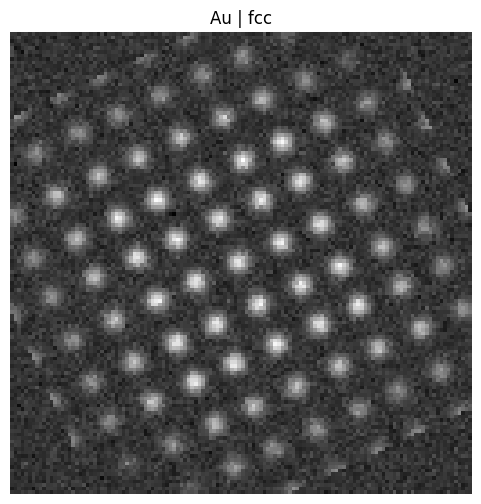

In [ ]:

material = MATERIALS[0]
image = generate_crystal_image(
    material,
    orientation='100',
    rotation_angle=25
)
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title(f"{material['element']} | "f"{material['structure']}")
plt.axis('off')
plt.show()

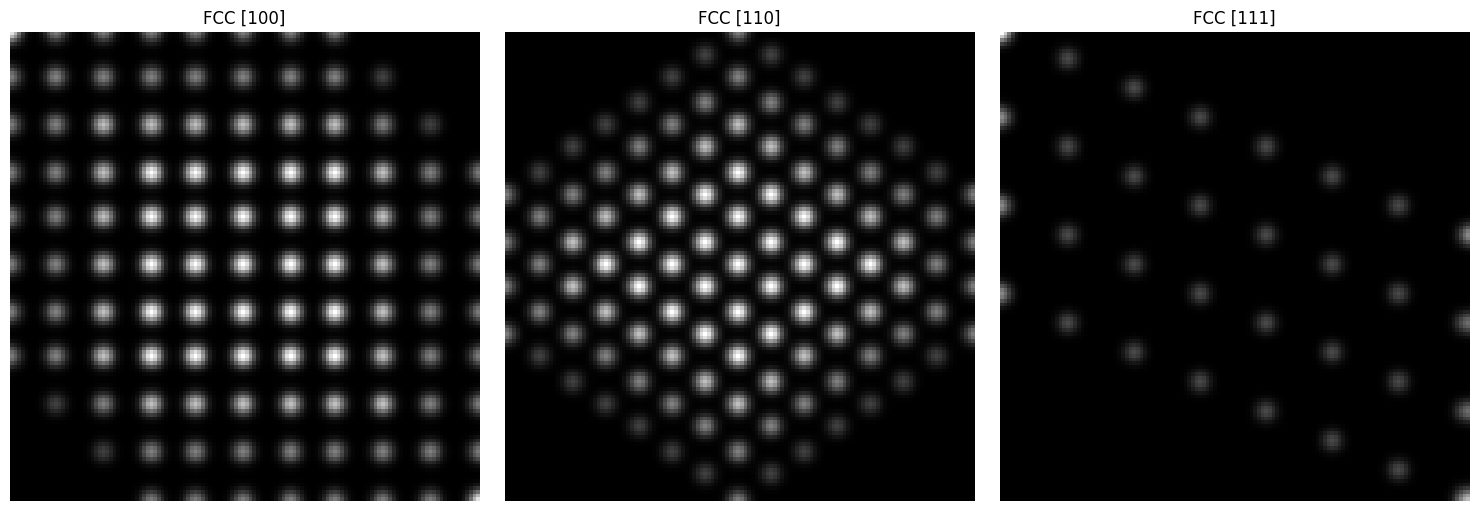

In [ ]:
material = MATERIALS[0]

orientations = ORIENTATIONS[material['structure']]

plt.figure(figsize=(15,5))

for i, orientation in enumerate(orientations):

    image = generate_crystal_image(
        material,
        orientation=orientation,
        rotation_angle=0,
        noise_level=0
    )

    plt.subplot(1, len(orientations), i+1)

    plt.imshow(image, cmap='gray')

    plt.title(f"{material['structure'].upper()} [{orientation}]")

    plt.axis('off')

plt.tight_layout()

plt.show()

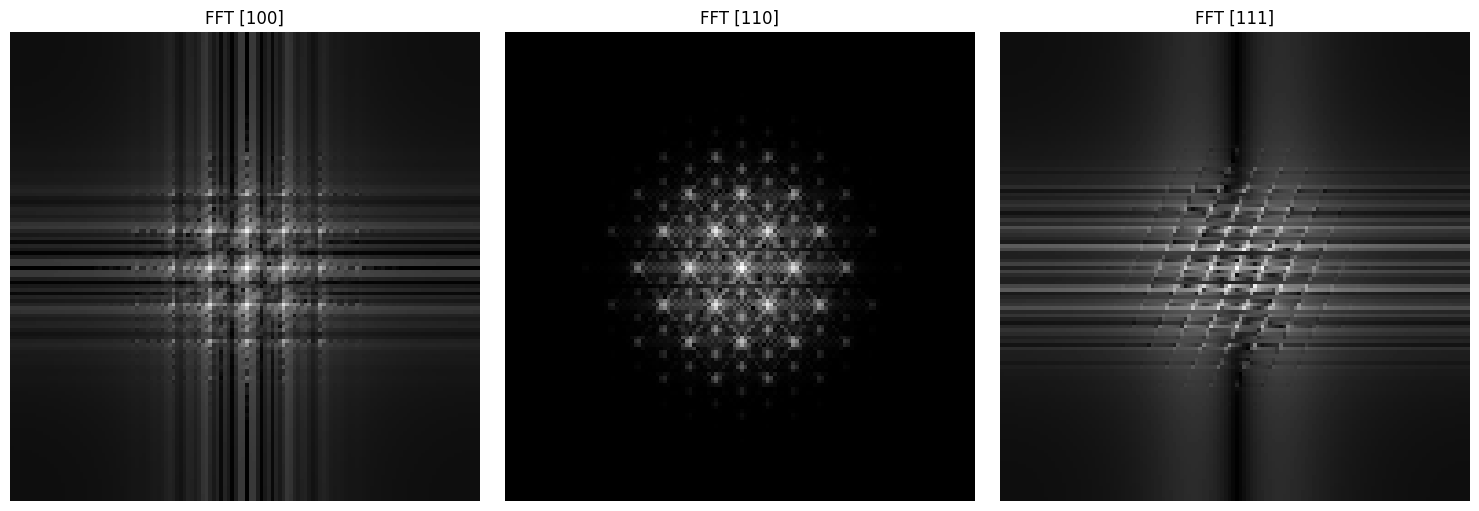

In [ ]:
material = MATERIALS[0]

orientations = ORIENTATIONS[material['structure']]

plt.figure(figsize=(15,5))

for i, orientation in enumerate(orientations):

    image = generate_crystal_image(
        material,
        orientation=orientation,
        rotation_angle=0,
        noise_level=0
    )

    fft = np.fft.fftshift(np.fft.fft2(image))

    magnitude = np.log(np.abs(fft) + 1)

    plt.subplot(1, len(orientations), i+1)

    plt.imshow(magnitude, cmap='gray')

    plt.title(f"FFT [{orientation}]")

    plt.axis('off')

plt.tight_layout()

plt.show()

In [ ]:
os.makedirs("dataset/images", exist_ok=True)
metadata_list = []
sample_id = 0
for material in MATERIALS:
    structure = material['structure']
    for orientation in ORIENTATIONS[structure]:
        for rotation in range(0, 180, 15):
            for noise_level in [0.005, 0.01, 0.02]:
                image = generate_crystal_image(
                    material,
                    orientation=orientation,
                    rotation_angle=rotation,
                    noise_level=noise_level
                )
                filename = f"sample_{sample_id:04d}.npy"
                np.save(f"dataset/images/{filename}", image)
                metadata_list.append({
                    'filename': filename,
                    'element': material['element'],
                    'structure': material['structure'],
                    'orientation': orientation,
                    'rotation': rotation,
                    'noise_level': noise_level
                })
                sample_id += 1
metadata_df = pd.DataFrame(metadata_list)
metadata_df.to_csv("dataset/metadata.csv", index=False)

print("Dataset generation complete.")
print(f"Total samples: {sample_id}")

Dataset generation complete.
Total samples: 1728


In [ ]:
from skimage import filters
from scipy.ndimage import convolve
from skimage.feature import corner_peaks


def harris_corners(img, window_size=3, k=0.04):
    H, W = img.shape
    window = np.ones((window_size, window_size))
    dx = filters.sobel_v(img)
    dy = filters.sobel_h(img)
    Ixx = dx * dx
    Iyy = dy * dy
    Ixy = dx * dy

    Sxx = convolve(Ixx, window, mode='constant', cval=0)
    Syy = convolve(Iyy, window, mode='constant', cval=0)
    Sxy = convolve(Ixy, window, mode='constant', cval=0)

    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy
    response = det_M - k * (trace_M ** 2)
    return response

Detected coordinates:
[[64 64]
 [74 64]
 [54 64]
 [64 74]
 [64 54]
 [74 54]
 [54 74]
 [54 54]
 [74 74]
 [74 44]
 [54 84]
 [64 84]
 [64 44]
 [84 64]
 [44 64]
 [84 74]
 [44 54]
 [44 74]
 [84 54]
 [74 84]]

Peak distances:
[10.         10.         10.         10.         14.14213562 14.14213562
 14.14213562 14.14213562 22.36067977 22.36067977 20.         20.
 20.         20.         22.36067977 22.36067977 22.36067977 22.36067977
 22.36067977]


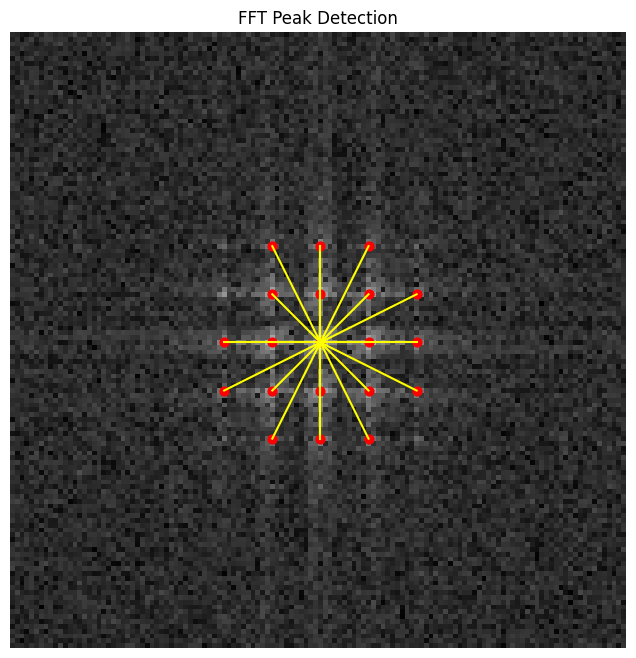

In [ ]:
#Test the Fourier Transform
sample = np.load("dataset/images/sample_0000.npy")
fft = np.fft.fftshift(np.fft.fft2(sample))
magnitude = np.log(np.abs(fft) + 1)
response = harris_corners(magnitude, window_size=3, k=0.04)

coordinates = corner_peaks(
    response,
    threshold_rel=0.05,
    exclude_border=8,
    num_peaks=20
)

print("Detected coordinates:")
print(coordinates)

# FFT center
center_y = magnitude.shape[0] // 2
center_x = magnitude.shape[1] // 2


distances = []
for coord in coordinates:
    y, x = coord
    # Skipping center peak
    if abs(x - center_x) < 5 and abs(y - center_y) < 5:
        continue
    distance = np.sqrt((x - center_x)**2 +(y - center_y)**2)
    distances.append(distance)

distances = np.array(distances)

print("\nPeak distances:")
print(distances)

# Visualize FFT peaks
plt.figure(figsize=(8,8))
plt.imshow(magnitude, cmap='gray')
plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

for coord in coordinates:
    y, x = coord
    plt.plot(
        [center_x, x],
        [center_y, y],
        'yellow'
    )

plt.title("FFT Peak Detection")
plt.axis('off')
plt.show()

In [ ]:
#Test the locations of the peaks
mean_distance = np.mean(distances)
std_distance = np.std(distances)
min_distance = np.min(distances)
max_distance = np.max(distances)
num_peaks = len(distances)

print("Mean distance:", mean_distance)
print("Std distance:", std_distance)
print("Min distance:", min_distance)
print("Max distance:", max_distance)
print("Number of peaks:", num_peaks)

Mean distance: 17.53122636420574
Std distance: 4.922910677170428
Min distance: 10.0
Max distance: 22.360679774997898
Number of peaks: 19


In [ ]:
distance_feature_data = []

for idx in range(len(metadata_df)):

    filename = metadata_df.iloc[idx]['filename']
    structure = metadata_df.iloc[idx]['structure']
    image = np.load(f"dataset/images/{filename}")
    fft = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log(np.abs(fft) + 1)
    response = harris_corners(magnitude,window_size=3,k=0.04)

    coordinates = corner_peaks(
      response,
      threshold_rel=0.05,
      exclude_border=8,
      num_peaks=20
    )

    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    distances = []
    for coord in coordinates:
        y, x = coord
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        distances.append(distance)

    distances = np.array(distances)

    if len(distances) == 0:
        continue

    distance_feature_data.append({
        'filename': filename,
        'mean_distance': np.mean(distances),
        'std_distance': np.std(distances),
        'min_distance': np.min(distances),
        'max_distance': np.max(distances),
        'num_peaks': len(distances),
        'structure': structure
    })

distance_features_df = pd.DataFrame(distance_feature_data)
print(distance_features_df.head())

          filename  mean_distance  std_distance  min_distance  max_distance  \
0  sample_0000.npy      17.531226      4.922911     10.000000     22.360680   
1  sample_0001.npy      17.531226      4.922911     10.000000     22.360680   
2  sample_0002.npy      14.714045      4.102464     10.000000     20.000000   
3  sample_0003.npy      17.828306      4.988823     10.198039     22.671568   
4  sample_0004.npy      17.681708      5.025131      9.486833     22.671568   

   num_peaks structure  
0         19       fcc  
1         19       fcc  
2         12       fcc  
3         19       fcc  
4         19       fcc  


In [ ]:
angular_feature_data = []
for idx in range(len(metadata_df)):
    filename = metadata_df.iloc[idx]['filename']
    image = np.load(f"dataset/images/{filename}")
    fft = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log(np.abs(fft) + 1)
    response = harris_corners(magnitude,window_size=3,k=0.04)
    coordinates = corner_peaks(
      response,
      threshold_rel=0.05,
      exclude_border=8,
      num_peaks=20
    )
    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2
    angles = []
    for coord in coordinates:
        y, x = coord
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue
        angle = np.degrees(np.arctan2(y - center_y, x - center_x)) % 360
        angles.append(angle)
    angles = np.array(angles)
    if len(angles) < 2:
        continue
    angles_sorted = np.sort(angles)
    angular_diffs = np.diff(np.concatenate([angles_sorted, [angles_sorted[0] + 360]]))
    angular_feature_data.append({
        'filename': filename,
        'mean_angular_diff': np.mean(angular_diffs),
        'std_angular_diff': np.std(angular_diffs),
    })
angular_features_df = pd.DataFrame(angular_feature_data)
print(angular_features_df.head())

          filename  mean_angular_diff  std_angular_diff
0  sample_0000.npy          18.947368         11.522957
1  sample_0001.npy          18.947368         11.522957
2  sample_0002.npy          30.000000         21.213203
3  sample_0003.npy          18.947368         10.101320
4  sample_0004.npy          18.947368         10.204579


In [ ]:
features_df = distance_features_df.merge(angular_features_df, on='filename')
print(features_df.head())

          filename  mean_distance  std_distance  min_distance  max_distance  \
0  sample_0000.npy      17.531226      4.922911     10.000000     22.360680   
1  sample_0001.npy      17.531226      4.922911     10.000000     22.360680   
2  sample_0002.npy      14.714045      4.102464     10.000000     20.000000   
3  sample_0003.npy      17.828306      4.988823     10.198039     22.671568   
4  sample_0004.npy      17.681708      5.025131      9.486833     22.671568   

   num_peaks structure  mean_angular_diff  std_angular_diff  
0         19       fcc          18.947368         11.522957  
1         19       fcc          18.947368         11.522957  
2         12       fcc          30.000000         21.213203  
3         19       fcc          18.947368         10.101320  
4         19       fcc          18.947368         10.204579  


In [ ]:
features_df['structure'].value_counts()

,count
structure,
fcc,648
bcc,648
hcp,432


In [ ]:
from sklearn.model_selection import train_test_split

X = features_df[[
    'mean_distance',
    'std_distance',
    'min_distance',
    'max_distance',
    'num_peaks',
    'mean_angular_diff',
    'std_angular_diff',
]]

y = features_df['structure']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=6
)

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 1382
Testing samples: 346


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create classifier
classifier = RandomForestClassifier(n_estimators=100,random_state=6)

# Train classifier
classifier.fit(X_train, y_train)

# Predict structures
predictions = classifier.predict(X_test)

# Display results
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         bcc       0.93      0.97      0.95       119
         fcc       0.98      0.94      0.96       144
         hcp       0.96      0.96      0.96        83

    accuracy                           0.96       346
   macro avg       0.96      0.96      0.96       346
weighted avg       0.96      0.96      0.96       346



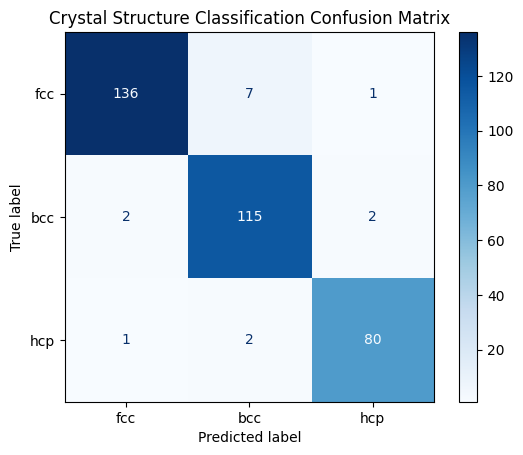

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, predictions,
    labels=['fcc', 'bcc', 'hcp'],
    cmap='Blues'
)
plt.title("Crystal Structure Classification Confusion Matrix")
plt.show()

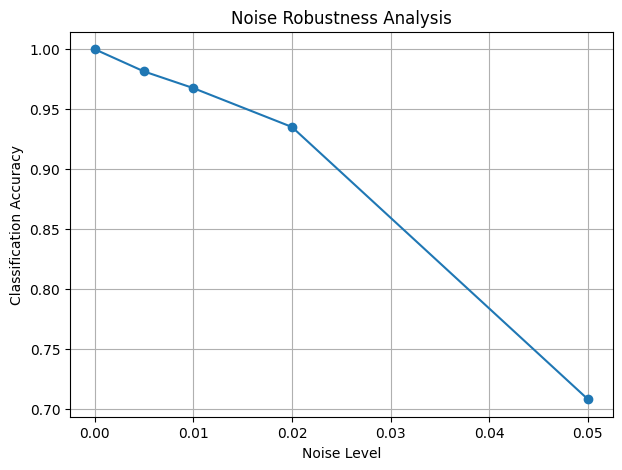

In [ ]:
#Noise Robustness Analysis
noise_levels = [0.0, 0.005, 0.01, 0.02, 0.05]
noise_accuracies = []
for noise_level in noise_levels:
    test_feature_data = []
    for material in MATERIALS:
        for rotation in range(0, 180, 15):
            image = generate_crystal_image(material, rotation_angle=rotation, noise_level=noise_level)
            fft = np.fft.fftshift(np.fft.fft2(image))
            magnitude = np.log(np.abs(fft) + 1)
            response = harris_corners(magnitude, window_size=3, k=0.04)
            coordinates = corner_peaks(response, threshold_rel=0.05, exclude_border=8, num_peaks=20)
            center_y = magnitude.shape[0] // 2
            center_x = magnitude.shape[1] // 2
            distances = []
            for coord in coordinates:
                y, x = coord
                if abs(x - center_x) < 5 and abs(y - center_y) < 5:
                    continue
                distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                distances.append(distance)
            distances = np.array(distances)
            if len(distances) == 0:
                continue
            angles = []
            for coord in coordinates:
                y, x = coord
                if abs(x - center_x) < 5 and abs(y - center_y) < 5:
                    continue
                angle = np.degrees(np.arctan2(y - center_y, x - center_x)) % 360
                angles.append(angle)

            angles = np.array(angles)

            if len(angles) < 2:
                continue

            angles_sorted = np.sort(angles)
            angular_diffs = np.diff(np.concatenate([angles_sorted, [angles_sorted[0] + 360]]))
            test_feature_data.append({
                'mean_distance': np.mean(distances),
                'std_distance': np.std(distances),
                'min_distance': np.min(distances),
                'max_distance': np.max(distances),
                'num_peaks': len(distances),
                'mean_angular_diff': np.mean(angular_diffs),
                'std_angular_diff': np.std(angular_diffs),
                'structure': material['structure']
            })

    robustness_df = pd.DataFrame(test_feature_data)
    X_noise = robustness_df[['mean_distance', 'std_distance', 'min_distance', 'max_distance', 'num_peaks', 'mean_angular_diff', 'std_angular_diff']]
    y_noise = robustness_df['structure']
    predictions = classifier.predict(X_noise)
    accuracy = np.mean(predictions == y_noise)
    noise_accuracies.append(accuracy)

plt.figure(figsize=(7,5))
plt.plot(noise_levels, noise_accuracies, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("Classification Accuracy")
plt.title("Noise Robustness Analysis")
plt.grid()
plt.show()

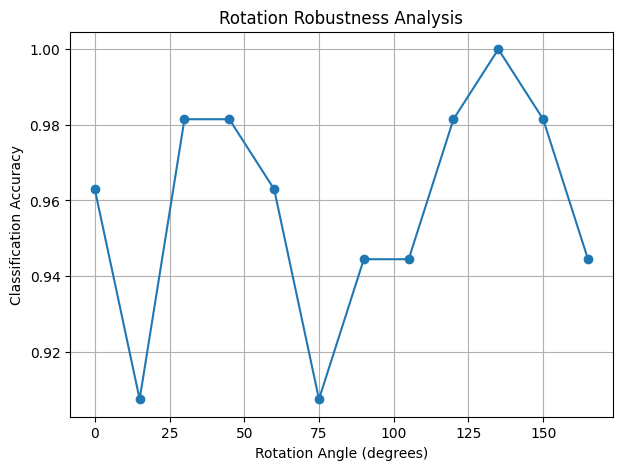

In [ ]:
rotation_angles = range(0, 180, 15)
rotation_accuracies = []
for rotation_angle in rotation_angles:
    test_feature_data = []
    for material in MATERIALS:
        for noise_level in [0.005, 0.01, 0.02]:
            image = generate_crystal_image(material, rotation_angle=rotation_angle, noise_level=noise_level)
            fft = np.fft.fftshift(np.fft.fft2(image))
            magnitude = np.log(np.abs(fft) + 1)
            response = harris_corners(magnitude, window_size=3, k=0.04)
            coordinates = corner_peaks(response, threshold_rel=0.05, exclude_border=8, num_peaks=20)

            center_y = magnitude.shape[0] // 2
            center_x = magnitude.shape[1] // 2

            distances = []

            for coord in coordinates:
                y, x = coord
                if abs(x - center_x) < 5 and abs(y - center_y) < 5:
                    continue
                distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                distances.append(distance)

            distances = np.array(distances)
            if len(distances) == 0:
                continue
            angles = []
            for coord in coordinates:
                y, x = coord
                if abs(x - center_x) < 5 and abs(y - center_y) < 5:
                    continue

                angle = np.degrees(np.arctan2(y - center_y, x - center_x)) % 360
                angles.append(angle)

            angles = np.array(angles)

            if len(angles) < 2:
                continue

            angles_sorted = np.sort(angles)
            angular_diffs = np.diff(np.concatenate([angles_sorted, [angles_sorted[0] + 360]]))
            test_feature_data.append({
                'mean_distance': np.mean(distances),
                'std_distance': np.std(distances),
                'min_distance': np.min(distances),
                'max_distance': np.max(distances),
                'num_peaks': len(distances),
                'mean_angular_diff': np.mean(angular_diffs),
                'std_angular_diff': np.std(angular_diffs),
                'structure': material['structure']
            })

    robustness_df = pd.DataFrame(test_feature_data)
    X_rotation = robustness_df[['mean_distance', 'std_distance', 'min_distance', 'max_distance', 'num_peaks', 'mean_angular_diff', 'std_angular_diff']]
    y_rotation = robustness_df['structure']
    predictions = classifier.predict(X_rotation)
    accuracy = np.mean(predictions == y_rotation)
    rotation_accuracies.append(accuracy)

plt.figure(figsize=(7,5))
plt.plot(list(rotation_angles), rotation_accuracies, marker='o')
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Classification Accuracy")
plt.title("Rotation Robustness Analysis")
plt.grid()
plt.show()

In [ ]:
STRUCTURE_INFO = {

    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

In [ ]:
MATERIAL_PROPERTIES = {

    # FCC
    'Au': {'structure': 'fcc', 'a': 4.08, 'atomic_mass': 196.97},
    'Al': {'structure': 'fcc', 'a': 4.05, 'atomic_mass': 26.98},
    'Cu': {'structure': 'fcc', 'a': 3.61, 'atomic_mass': 63.55},
    'Ni': {'structure': 'fcc', 'a': 3.52, 'atomic_mass': 58.69},
    'Ag': {'structure': 'fcc', 'a': 4.09, 'atomic_mass': 107.87},
    'Pt': {'structure': 'fcc', 'a': 3.92, 'atomic_mass': 195.08},

    # BCC
    'Fe': {'structure': 'bcc', 'a': 2.87, 'atomic_mass': 55.85},
    'Cr': {'structure': 'bcc', 'a': 2.91, 'atomic_mass': 52.00},
    'W':  {'structure': 'bcc', 'a': 3.16, 'atomic_mass': 183.84},
    'Mo': {'structure': 'bcc', 'a': 3.15, 'atomic_mass': 95.95},
    'Nb': {'structure': 'bcc', 'a': 3.30, 'atomic_mass': 92.91},
    'V':  {'structure': 'bcc', 'a': 3.03, 'atomic_mass': 50.94},

    # HCP
    'Ti': {'structure': 'hcp', 'a': 2.95, 'c': 4.68, 'atomic_mass': 47.87},
    'Mg': {'structure': 'hcp', 'a': 3.21, 'c': 5.21, 'atomic_mass': 24.31},
    'Zn': {'structure': 'hcp', 'a': 2.66, 'c': 4.95, 'atomic_mass': 65.38},
    'Co': {'structure': 'hcp', 'a': 2.51, 'c': 4.07, 'atomic_mass': 58.93},
    'Zr': {'structure': 'hcp', 'a': 3.23, 'c': 5.15, 'atomic_mass': 91.22},
    'Be': {'structure': 'hcp', 'a': 2.29, 'c': 3.58, 'atomic_mass': 9.01},
}

In [ ]:
#this density calculation assumes ideal crystallographic densities based on lattice parameters.
#Thus, we assume that the calculated density is at near room temperature.
#We also assume that we have the lattice parameters 'a' and 'c', as these values can be determined from HRTEM measurements.
#Different crystallographic orientations produce different reciprocal-space
#patterns, but the density depends only on the underlying unit-cell geometry.
NA = 6.022e23

def calculate_density(material_name, predicted_structure):
    material = MATERIAL_PROPERTIES[material_name]
    atomic_mass = material['atomic_mass']
    n = STRUCTURE_INFO[predicted_structure]

    # FCC and BCC
    if predicted_structure in ['fcc', 'bcc']:
        a = material['a'] * 1e-8
        volume = a**3
    # HCP
    elif predicted_structure == 'hcp':
        a = material['a'] * 1e-8
        c = material['c'] * 1e-8
        volume = (3 * np.sqrt(3) / 2) * (a**2) * c

    density = (n * atomic_mass) / (volume * NA)

    return density

In [ ]:
# Example image index (this chooses gold as the sample)
sample_idx = 0
material_name = metadata_df.iloc[sample_idx]['element']
sample_features = X.iloc[[sample_idx]]

# Predict structure using ML model
predicted_structure = classifier.predict(sample_features)[0]

# Compute density using predicted structure
predicted_density = calculate_density(material_name,predicted_structure)

print("Material:", material_name)
print("Predicted structure:", predicted_structure)
print("Orientation:", metadata_df.iloc[sample_idx]['orientation'])
print("Predicted density:", predicted_density)

Material: Au
Predicted structure: fcc
Orientation: 100
Predicted density: 19.263661391121232
